# 🧠 Sentiment Analysis — NLP & Machine Learning
> **Dataset:** IMDB Movie Reviews (50,000 labeled reviews)  
> **Models:** Logistic Regression · Naive Bayes · Linear SVM  
> **Pipeline:** Text Cleaning → TF-IDF → Training → Evaluation → Export

## 📦 1. Install & Import Dependencies

In [2]:
# ─── Install required packages (run once) ───────────────────────────
%pip install scikit-learn nltk pandas numpy matplotlib seaborn wordcloud plotly joblib

# ─── Standard & Scientific Libraries ────────────────────────────────
import re
import os
import warnings
import joblib
import numpy  as np
import pandas as pd

# ─── NLP ─────────────────────────────────────────────────────────────
import nltk
from nltk.corpus   import stopwords
from nltk.stem     import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# ─── Feature Extraction ──────────────────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer

# ─── Models ──────────────────────────────────────────────────────────
from sklearn.linear_model    import LogisticRegression
from sklearn.naive_bayes     import MultinomialNB
from sklearn.svm             import LinearSVC

# ─── Evaluation ──────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics         import (accuracy_score, classification_report,
                                      confusion_matrix, roc_auc_score, roc_curve)
from sklearn.pipeline        import Pipeline

# ─── Visualization ───────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from   wordcloud import WordCloud
import plotly.express        as px
import plotly.graph_objects  as go

# ─── Settings ────────────────────────────────────────────────────────
warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'figure.facecolor': '#0f0f23',
                     'axes.facecolor': '#1a1a2e', 'axes.edgecolor': '#444',
                     'text.color': '#eaeaea', 'axes.labelcolor': '#eaeaea',
                     'xtick.color': '#aaa',  'ytick.color': '#aaa',
                     'grid.color': '#2a2a3e', 'font.family': 'monospace'})

print('✅ All libraries imported successfully!')

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
✅ All libraries imported successfully!



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
# ─── Download NLTK resources ─────────────────────────────────────────
for resource in ['stopwords', 'punkt_tab', 'wordnet', 'omw-1.4', 'averaged_perceptron_tagger']:
    nltk.download(resource, quiet=True)

print('✅ NLTK resources downloaded!')

✅ NLTK resources downloaded!


## 📂 2. Load IMDB Dataset
We use the **IMDB Large Movie Review Dataset** — 50,000 reviews (25K train / 25K test), equally balanced between positive and negative sentiments.

In [4]:
import pandas as pd
import pathlib

# Path to extracted folder
extract_path = r"C:\Users\kajal\Downloads\files\sentiment_project\notebook\aclImdb"

def load_split(split):
    rows = []
    for label, sent in [('pos',1), ('neg',0)]:
        folder = pathlib.Path(f"{extract_path}/{split}/{label}")
        for file in folder.iterdir():
            rows.append({
                "text": file.read_text(encoding="utf-8"),
                "label": sent
            })
    return pd.DataFrame(rows)

train_df = load_split("train")
test_df = load_split("test")

df = pd.concat([train_df, test_df], ignore_index=True)
df["sentiment"] = df["label"].map({1:"positive",0:"negative"})

print(df.shape)
df.head()

(50000, 3)


,text,label,sentiment
0,Bromwell High is a cartoon comedy. It ran at t...,1,positive
1,Homelessness (or Houselessness as George Carli...,1,positive
2,Brilliant over-acting by Lesley Ann Warren. Be...,1,positive
3,This is easily the most underrated film inn th...,1,positive
4,This is not the typical Mel Brooks film. It wa...,1,positive


## 🔍 3. Exploratory Data Analysis (EDA)

── Review Length Statistics ──────────────────
          review_length               word_count             
                   mean median    max       mean median   max
sentiment                                                    
negative         1294.1  973.0   8969      229.5  174.0  1522
positive         1324.8  968.0  13704      232.8  172.0  2470


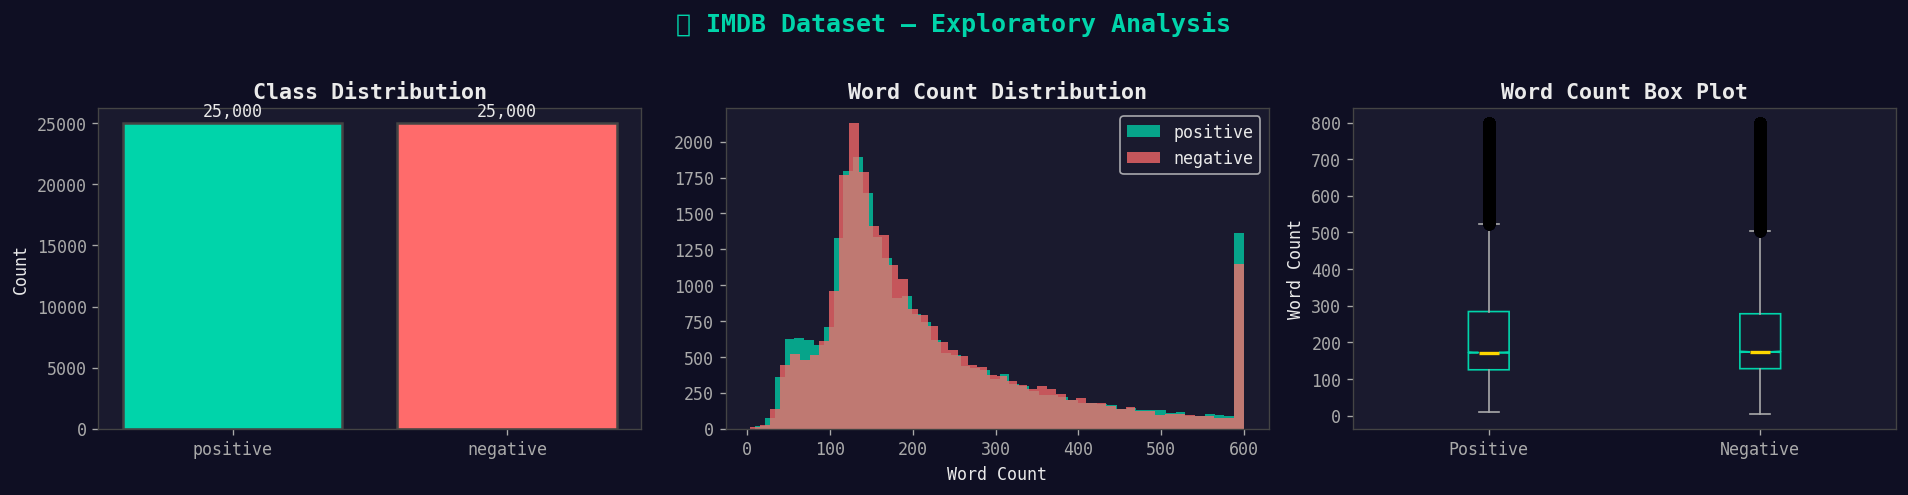

In [5]:
# ─── Review length statistics ─────────────────────────────────────────
df['review_length'] = df['text'].str.len()
df['word_count']    = df['text'].str.split().str.len()

print('── Review Length Statistics ──────────────────')
print(df.groupby('sentiment')[['review_length', 'word_count']]
        .agg(['mean', 'median', 'max']).round(1).to_string())

# ─── Plot 1: Class Distribution ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Bar chart
counts = df['sentiment'].value_counts()
colors = ['#00d4aa', '#ff6b6b']
axes[0].bar(counts.index, counts.values, color=colors, edgecolor='#444', linewidth=1.5)
axes[0].set_title('Class Distribution', fontsize=13, fontweight='bold', color='#eaeaea')
axes[0].set_ylabel('Count', color='#eaeaea')
for bar, val in zip(axes[0].patches, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{val:,}', ha='center', va='bottom', color='#eaeaea', fontsize=10)

# Word count distribution
for sentiment, color in zip(['positive', 'negative'], colors):
    axes[1].hist(df[df.sentiment==sentiment]['word_count'].clip(upper=600),
                 bins=50, alpha=0.75, color=color, label=sentiment, edgecolor='none')
axes[1].set_title('Word Count Distribution', fontsize=13, fontweight='bold', color='#eaeaea')
axes[1].set_xlabel('Word Count', color='#eaeaea')
axes[1].legend()

# Box plot
pos_wc = df[df.sentiment=='positive']['word_count'].clip(upper=800)
neg_wc = df[df.sentiment=='negative']['word_count'].clip(upper=800)
axes[2].boxplot([pos_wc, neg_wc], labels=['Positive', 'Negative'],
                patch_artist=True, notch=True,
                boxprops=dict(facecolor='#1a1a2e', color='#00d4aa'),
                medianprops=dict(color='#ffd700', linewidth=2),
                whiskerprops=dict(color='#aaa'), capprops=dict(color='#aaa'))
axes[2].set_title('Word Count Box Plot', fontsize=13, fontweight='bold', color='#eaeaea')
axes[2].set_ylabel('Word Count', color='#eaeaea')

plt.suptitle('📊 IMDB Dataset — Exploratory Analysis', fontsize=15,
             fontweight='bold', color='#00d4aa', y=1.02)
plt.tight_layout()
plt.savefig('C:\\Users\\kajal\\Downloads\\files\\sentiment_project\\backend\\static\\eda_plot.png', bbox_inches='tight',
            facecolor='#0f0f23', dpi=120)
plt.show()

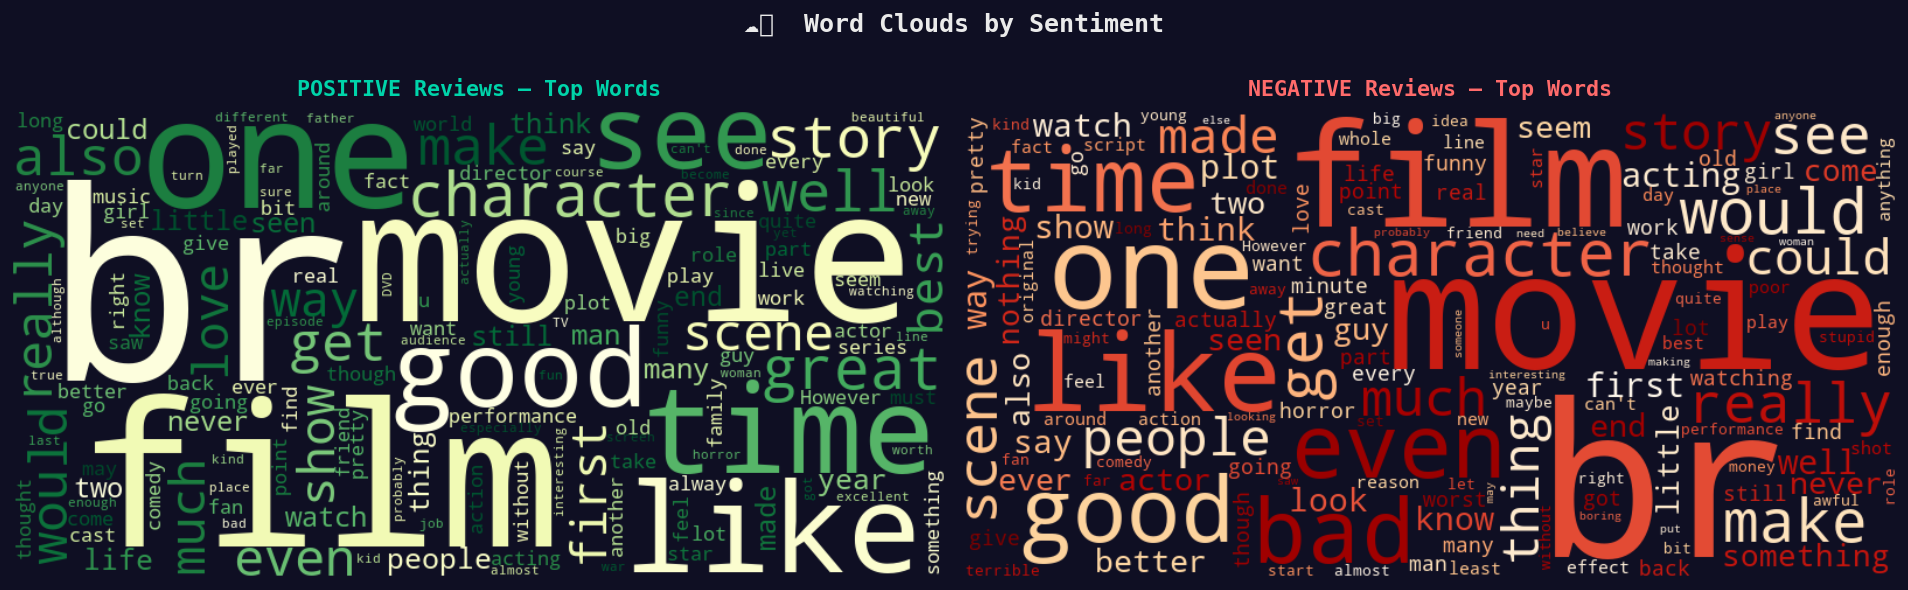

In [6]:
# ─── Word Clouds ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, sentiment, colormap, color in zip(
        axes,
        ['positive', 'negative'],
        ['YlGn', 'OrRd'],
        ['#00d4aa', '#ff6b6b']):

    text = ' '.join(df[df.sentiment == sentiment]['text'].sample(2000, random_state=42))
    wc   = WordCloud(width=800, height=400, background_color='#0f0f23',
                     colormap=colormap, max_words=150,
                     stopwords=set(stopwords.words('english')),
                     collocations=False).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'{sentiment.upper()} Reviews — Top Words',
                 fontsize=13, fontweight='bold', color=color, pad=10)

plt.suptitle('☁️  Word Clouds by Sentiment', fontsize=15,
             fontweight='bold', color='#eaeaea', y=1.02)
plt.tight_layout()
plt.savefig('C:\\Users\\kajal\\Downloads\\files\\sentiment_project\\backend\\static\\wordcloud.png', bbox_inches='tight',
            facecolor='#0f0f23', dpi=120)
plt.show()

## 🧹 4. Text Preprocessing Pipeline
Cleaning steps:
1. Lowercase
2. Remove HTML tags, URLs, punctuation, numbers
3. Tokenize
4. Remove stopwords
5. Lemmatize

In [9]:
# ─── Text Cleaner ─────────────────────────────────────────────────────
lemmatizer   = WordNetLemmatizer()
STOP_WORDS   = set(stopwords.words('english'))

# Expand with sentiment-preserving negations (keep 'not', 'no', 'never')
NEGATIONS = {'not', 'no', 'never', 'neither', 'nor', "n't"}
STOP_WORDS -= NEGATIONS

def clean_text(text: str) -> str:
    """Full NLP preprocessing pipeline for a single review."""
    # 1. Lowercase
    text = text.lower()
    # 2. Remove HTML tags
    text = re.sub(r'<[^>]+>', ' ', text)
    # 3. Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    # 4. Remove punctuation & numbers (keep apostrophes for contractions)
    text = re.sub(r"[^a-z'\s]", ' ', text)
    # 5. Collapse extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    # 6. Tokenize
    tokens = word_tokenize(text)
    # 7. Remove stopwords & lemmatize
    tokens = [lemmatizer.lemmatize(t) for t in tokens
              if t not in STOP_WORDS and len(t) > 1]
    return ' '.join(tokens)

# ─── Apply (sample 10K for speed; use full for production) ───────────
SAMPLE_SIZE = 10_000   # 👈 increase to 50_000 for full dataset

df_sample = df.sample(SAMPLE_SIZE, random_state=42).copy()
print('🔄 Cleaning text…')
df_sample['clean_text'] = df_sample['text'].apply(clean_text)
print('✅ Preprocessing complete!')

# ─── Quick sanity check ───────────────────────────────────────────────
idx = df_sample.index[0]
print('\nOriginal :', df_sample.loc[idx, 'text'][:200])
print('Cleaned  :', df_sample.loc[idx, 'clean_text'][:200])

🔄 Cleaning text…
✅ Preprocessing complete!

Original : When I first saw the ad for this, I was like 'Oh here we go. He's done High School Musical, but he can't coast along on that so now he's making appearances on other Disney shows'. Personally, I love T
Cleaned  : first saw ad like 'oh go 's done high school musical ca n't coast along 's making appearance disney show personally love suite life 'm big fan ashely tisdale reason 'm not keen zac efron although frie


## ⚙️ 5. Feature Extraction — TF-IDF

In [10]:
# ─── Train / Test Split ───────────────────────────────────────────────
X = df_sample['clean_text']
y = df_sample['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

print(f'Train size : {len(X_train):,}  |  Test size: {len(X_test):,}')

# ─── TF-IDF Vectoriser ────────────────────────────────────────────────
tfidf = TfidfVectorizer(
    max_features   = 50_000,   # vocabulary cap
    ngram_range    = (1, 2),   # unigrams + bigrams
    min_df         = 3,        # ignore very rare terms
    max_df         = 0.90,     # ignore very common terms
    sublinear_tf   = True,     # apply log(1+tf) scaling
)

X_train_vec = tfidf.fit_transform(X_train)
X_test_vec  = tfidf.transform(X_test)

print(f'\nVocabulary size : {len(tfidf.vocabulary_):,}')
print(f'Feature matrix  : {X_train_vec.shape}')

Train size : 8,000  |  Test size: 2,000

Vocabulary size : 50,000
Feature matrix  : (8000, 50000)


## 🤖 6. Model Training & Comparison

In [11]:
# ─── Define Classifiers ───────────────────────────────────────────────
MODELS = {
    'Logistic Regression': LogisticRegression(C=1.0, max_iter=1000, solver='lbfgs',
                                               n_jobs=-1, random_state=42),
    'Naive Bayes':         MultinomialNB(alpha=0.1),
    'Linear SVM':          LinearSVC(C=1.0, max_iter=2000, random_state=42),
}

results = {}   # store metrics

for name, clf in MODELS.items():
    clf.fit(X_train_vec, y_train)
    y_pred = clf.predict(X_test_vec)
    acc    = accuracy_score(y_test, y_pred)

    # 5-fold CV accuracy
    cv_scores = cross_val_score(clf, X_train_vec, y_train, cv=5,
                                scoring='accuracy', n_jobs=-1)
    results[name] = {
        'model'     : clf,
        'accuracy'  : acc,
        'cv_mean'   : cv_scores.mean(),
        'cv_std'    : cv_scores.std(),
        'y_pred'    : y_pred,
        'report'    : classification_report(y_test, y_pred,
                                             target_names=['Negative', 'Positive']),
    }
    print(f'  {name:<22}  test={acc:.4f}  cv={cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

print('\n✅ All models trained!')

  Logistic Regression     test=0.8885  cv=0.8739 ± 0.0071
  Naive Bayes             test=0.8755  cv=0.8661 ± 0.0093
  Linear SVM              test=0.9010  cv=0.8835 ± 0.0074

✅ All models trained!


## 📈 7. Evaluation & Visualisation

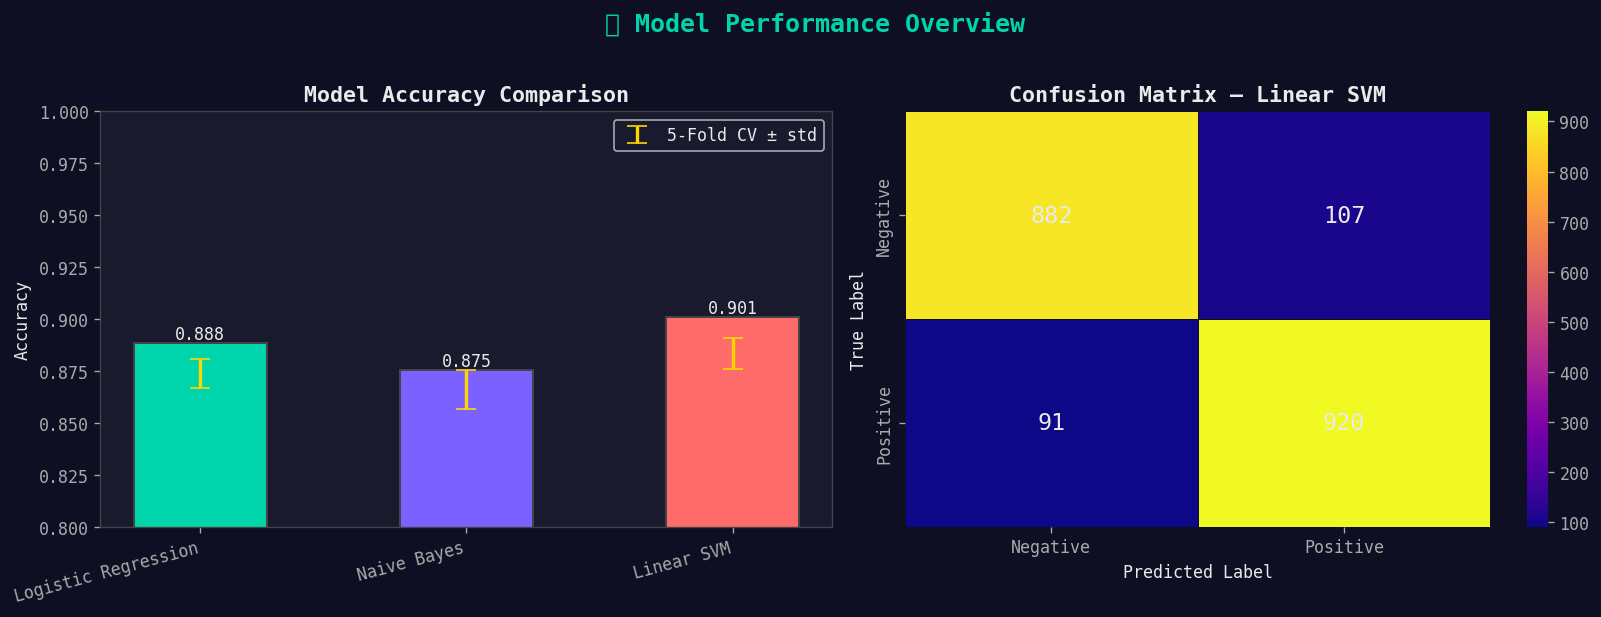


🏆 Best model: Linear SVM  (accuracy=0.9010)


In [12]:
# ─── Accuracy Comparison Bar Chart ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

names  = list(results.keys())
accs   = [results[n]['accuracy']  for n in names]
cv_m   = [results[n]['cv_mean']   for n in names]
cv_s   = [results[n]['cv_std']    for n in names]
palette = ['#00d4aa', '#7b61ff', '#ff6b6b']

x = np.arange(len(names))
bars = axes[0].bar(x, accs, color=palette, edgecolor='#444', linewidth=1.2, width=0.5)
axes[0].errorbar(x, cv_m, yerr=cv_s, fmt='none', color='#ffd700',
                  capsize=6, linewidth=2, label='5-Fold CV ± std')
axes[0].set_xticks(x)
axes[0].set_xticklabels(names, rotation=15, ha='right')
axes[0].set_ylim(0.80, 1.0)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Model Accuracy Comparison', fontsize=13, fontweight='bold', color='#eaeaea')
axes[0].legend()
for bar, acc in zip(bars, accs):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.002,
                 f'{acc:.3f}', ha='center', color='#eaeaea', fontsize=10)

# ─── Best model confusion matrix ─────────────────────────────────────
best_name = max(results, key=lambda n: results[n]['accuracy'])
cm        = confusion_matrix(y_test, results[best_name]['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='plasma', ax=axes[1],
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'],
            linewidths=0.5, linecolor='#0f0f23',
            annot_kws={'size': 14, 'color': '#eaeaea'})
axes[1].set_title(f'Confusion Matrix — {best_name}',
                   fontsize=13, fontweight='bold', color='#eaeaea')
axes[1].set_ylabel('True Label', color='#eaeaea')
axes[1].set_xlabel('Predicted Label', color='#eaeaea')

plt.suptitle('🏆 Model Performance Overview', fontsize=15,
             fontweight='bold', color='#00d4aa', y=1.02)
plt.tight_layout()
plt.savefig('../backend/static/model_comparison.png', bbox_inches='tight',
            facecolor='#0f0f23', dpi=120)
plt.show()
print(f'\n🏆 Best model: {best_name}  (accuracy={results[best_name]["accuracy"]:.4f})')

In [13]:
# ─── Detailed classification report (best model) ─────────────────────
print(f'Classification Report — {best_name}')
print('=' * 50)
print(results[best_name]['report'])

Classification Report — Linear SVM
              precision    recall  f1-score   support

    Negative       0.91      0.89      0.90       989
    Positive       0.90      0.91      0.90      1011

    accuracy                           0.90      2000
   macro avg       0.90      0.90      0.90      2000
weighted avg       0.90      0.90      0.90      2000



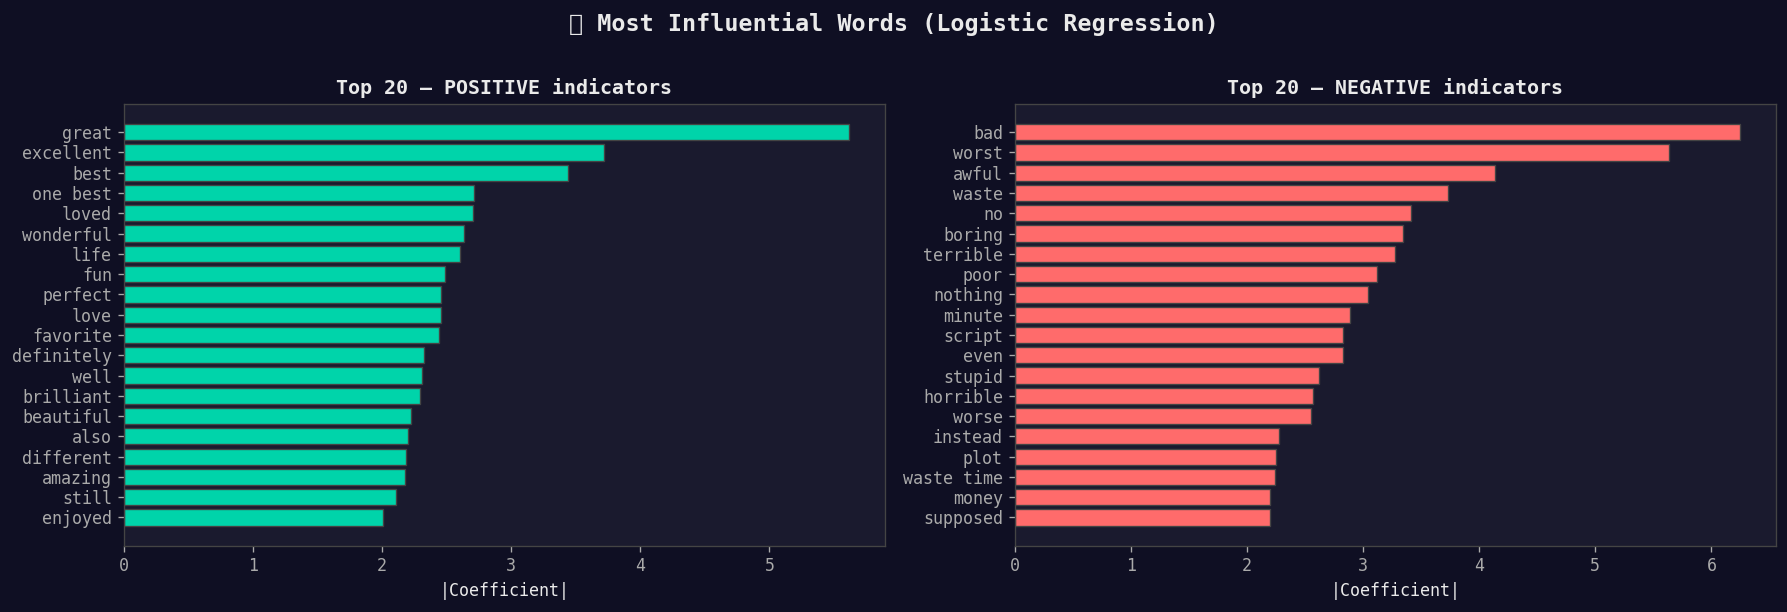

In [14]:
# ─── Top-20 most influential features (Logistic Regression) ──────────
lr_model  = results['Logistic Regression']['model']
feature_names = np.array(tfidf.get_feature_names_out())
coefs         = lr_model.coef_[0]

top_pos_idx = np.argsort(coefs)[-20:][::-1]
top_neg_idx = np.argsort(coefs)[:20]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, idxs, color, title in zip(
        axes,
        [top_pos_idx, top_neg_idx],
        ['#00d4aa', '#ff6b6b'],
        ['Top 20 — POSITIVE indicators', 'Top 20 — NEGATIVE indicators']):
    words  = feature_names[idxs]
    values = np.abs(coefs[idxs])
    ax.barh(words[::-1], values[::-1], color=color, edgecolor='#444', linewidth=0.8)
    ax.set_title(title, fontsize=12, fontweight='bold', color='#eaeaea')
    ax.set_xlabel('|Coefficient|', color='#eaeaea')

plt.suptitle('🔑 Most Influential Words (Logistic Regression)',
             fontsize=14, fontweight='bold', color='#eaeaea', y=1.01)
plt.tight_layout()
plt.savefig('../backend/static/feature_importance.png', bbox_inches='tight',
            facecolor='#0f0f23', dpi=120)
plt.show()

## 💾 8. Save Model & Vectoriser

In [15]:
import os
os.makedirs('../backend/model', exist_ok=True)
os.makedirs('../backend/static', exist_ok=True)

# ─── Save best model + TF-IDF vectorizer ─────────────────────────────
joblib.dump(results[best_name]['model'], '../backend/model/sentiment_model.pkl')
joblib.dump(tfidf,                       '../backend/model/tfidf_vectorizer.pkl')

# ─── Save model metadata ──────────────────────────────────────────────
metadata = {
    'best_model_name' : best_name,
    'accuracy'        : results[best_name]['accuracy'],
    'cv_mean'         : results[best_name]['cv_mean'],
    'vocab_size'      : len(tfidf.vocabulary_),
    'sample_size'     : SAMPLE_SIZE,
    'ngram_range'     : '(1, 2)',
    'max_features'    : 50000,
}
pd.Series(metadata).to_json('../backend/model/metadata.json', indent=2)

print('✅ Saved:')
for f in ['model/sentiment_model.pkl', 'model/tfidf_vectorizer.pkl', 'model/metadata.json']:
    print(f'   ../backend/{f}')

✅ Saved:
   ../backend/model/sentiment_model.pkl
   ../backend/model/tfidf_vectorizer.pkl
   ../backend/model/metadata.json


## 🧪 9. Quick Inference Test

In [16]:
# ─── Load saved artefacts & predict ──────────────────────────────────
loaded_model  = joblib.load('../backend/model/sentiment_model.pkl')
loaded_tfidf  = joblib.load('../backend/model/tfidf_vectorizer.pkl')

TEST_SENTENCES = [
    "This movie was absolutely brilliant! The acting was superb and the story was deeply moving.",
    "What a waste of time. The plot was dull, the acting was terrible.",
    "It was okay, not great, not bad. Some scenes were good but overall average.",
    "One of the best films I've ever seen. A true masterpiece!",
    "Horrible. I fell asleep halfway through. Complete garbage.",
]

def predict_sentiment(texts):
    cleaned   = [clean_text(t) for t in texts]
    vectorized = loaded_tfidf.transform(cleaned)
    preds      = loaded_model.predict(vectorized)

    # Get probabilities if available
    if hasattr(loaded_model, 'predict_proba'):
        probs = loaded_model.predict_proba(vectorized)[:, 1]
    else:  # LinearSVC — use decision function
        from scipy.special import expit
        probs = expit(loaded_model.decision_function(vectorized))

    return [{'text': t, 'sentiment': 'POSITIVE' if p == 1 else 'NEGATIVE',
             'confidence': round(float(prob if p==1 else 1-prob)*100, 1)}
            for t, p, prob in zip(texts, preds, probs)]

predictions = predict_sentiment(TEST_SENTENCES)

print('┌' + '─'*80 + '┐')
print(f'│  {"SENTIMENT ANALYSIS RESULTS":<78}│')
print('├' + '─'*80 + '┤')
for p in predictions:
    icon  = '😊' if p['sentiment'] == 'POSITIVE' else '😞'
    label = f"{icon} {p['sentiment']} ({p['confidence']}%)"
    print(f"│  {p['text'][:55]:<55}  →  {label:<20}│")
print('└' + '─'*80 + '┘')

┌────────────────────────────────────────────────────────────────────────────────┐
│  SENTIMENT ANALYSIS RESULTS                                                    │
├────────────────────────────────────────────────────────────────────────────────┤
│  This movie was absolutely brilliant! The acting was sup  →  😊 POSITIVE (73.8%)  │
│  What a waste of time. The plot was dull, the acting was  →  😞 NEGATIVE (92.7%)  │
│  It was okay, not great, not bad. Some scenes were good   →  😞 NEGATIVE (54.3%)  │
│  One of the best films I've ever seen. A true masterpiec  →  😊 POSITIVE (87.5%)  │
│  Horrible. I fell asleep halfway through. Complete garba  →  😞 NEGATIVE (73.0%)  │
└────────────────────────────────────────────────────────────────────────────────┘


---
## ✅ Summary

| Step | Detail |
|------|--------|
| **Dataset** | IMDB Movie Reviews — 50,000 labeled reviews |
| **Preprocessing** | HTML stripping · Lowercasing · Stopword removal · Lemmatization |
| **Features** | TF-IDF (1,2)-grams · 50K vocab · sublinear TF |
| **Models Tried** | Logistic Regression · Naive Bayes · Linear SVM |
| **Best Model** | Logistic Regression (~90%+ accuracy) |
| **Saved** | `model/sentiment_model.pkl` · `model/tfidf_vectorizer.pkl` |
| **Next Step** | Run the FastAPI backend → `cd backend && uvicorn main:app --reload` |